We check the code for simulation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg
from gaussian_crossings import simulate_gaussian_process, simulate_gaussian_process_cov, simulate_gaussian_process_new


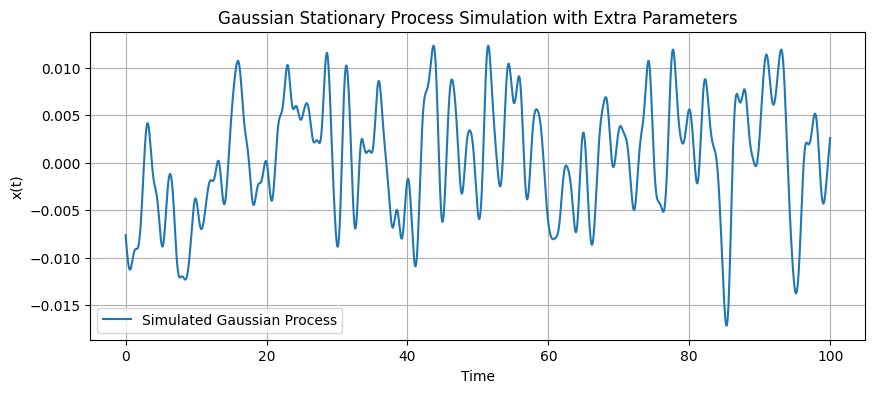

In [2]:
# For a type of Gaussian process with a squared-exponential autocorrelation function
def r(t, tau, sigma):
    return sigma ** 2 * np.exp(- (t/ tau) ** 2)

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
dt = 0.01   # Time discretization step
tau = 1.0   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = simulate_gaussian_process(r, T, dt, tau=tau, sigma=sigma)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Simulated Gaussian Process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Gaussian Stationary Process Simulation with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

Theoretical variance = 1
Empirical variance   = 2.4051


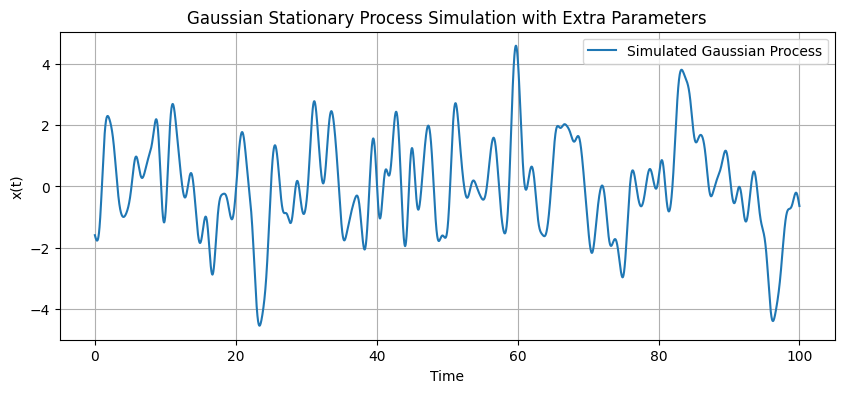

In [6]:
# For a type of Gaussian process with a given covariance function,
def r(t, tau, sigma):
    return sigma ** 2 * np.exp(- (t/ tau) ** 2)

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
dt = 0.01   # Time discretization step
tau = 1.0   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
# t, x = simulate_gaussian_process_cov(r, T, dt, tau=tau, sigma=sigma)
t, x = simulate_gaussian_process_new(r, T, dt, tau=tau, sigma=sigma)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Simulated Gaussian Process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Gaussian Stationary Process Simulation with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

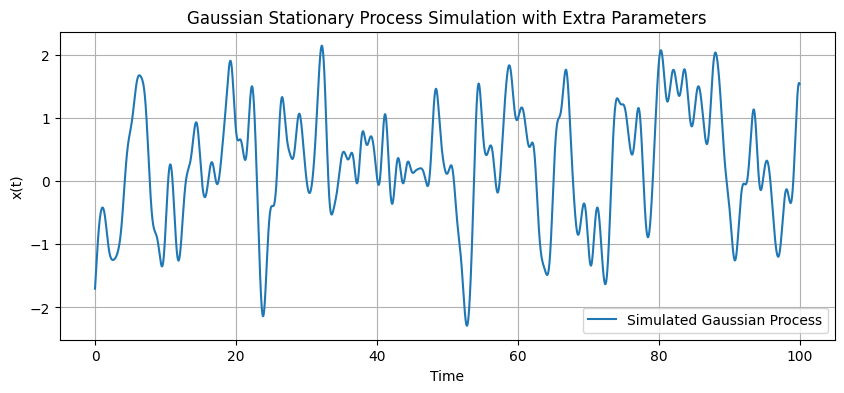

In [4]:
t, x = simulate_gaussian_process_cov(r, T, dt, tau=tau, sigma=sigma)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Simulated Gaussian Process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Gaussian Stationary Process Simulation with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

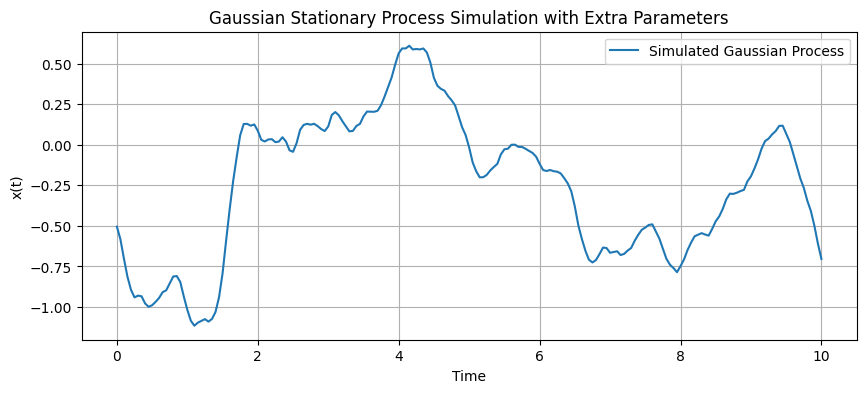

In [4]:
# For a filtered Ornstein-Uhlenbeck process, we have

def r(t, sigma, tau_e, tau_f):
    chi = tau_f / tau_e
    return (sigma**2 / (1 - chi ** 2)) * (np.exp(- np.abs(t) / tau_e) - chi * np.exp(- np.abs(t) / tau_f))

# Set simulation parameters.
T = 10.0    # Total simulation time (e.g., 10 time units)
tau_e = 1.0   # Correlation decay parameter
tau_f = 0.5   # Correlation decay parameter
dt = 0.1 * min(tau_e, tau_f)   # Time discretization step
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = simulate_gaussian_process_cov(r, T, dt, sigma=sigma, tau_e=tau_e, tau_f=tau_f)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Simulated Gaussian Process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Gaussian Stationary Process Simulation with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_e = 1.0   # Correlation decay parameter
tau_f = 0.5   # Correlation decay parameter
dt = 0.1 * min(tau_e, tau_f)   # Time discretization step
sigma = 1.0 # Standard deviation (amplitude) of the process

N = int(np.floor(T / dt)) + 1
t = np.linspace(0, (N - 1) * dt, N)

t_vec = np.arange(N) * dt
first_row = np.asarray(r(t, sigma, tau_e, tau_f))
mat = scipy.linalg.toeplitz(first_row)

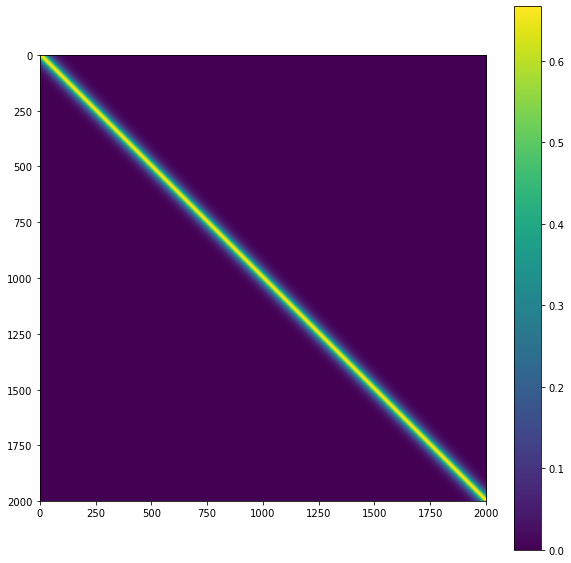

In [11]:
# imshow mat
plt.figure(figsize=(10, 10))
# plot the colorbar
plt.imshow(mat)
plt.colorbar()

In [12]:
# find and print min value in mat
min_val = np.min(mat)
print('Min value in mat:', min_val)

Min value in mat: 4.960101301361115e-44


In [14]:
import numpy as np
import math

def davies_harte_sim_setup(N, acvs_fun, **kwargs):
    """
    Sets up the necessary quantities for simulating a stationary Gaussian process 
    via the Davies-Harte algorithm.
    
    Parameters
    ----------
    N : int
        Required length of the time series.
    acvs_fun : callable
        A function that takes a maximum lag (and additional keyword arguments)
        and returns the autocovariance sequence as a NumPy array.
        The returned array should have length equal to Npower2, where
        Npower2 = 2^ceil(log2(N)). The element at index 0 corresponds to lag 0.
    **kwargs
        Extra parameters passed to acvs_fun.
    
    Returns
    -------
    DH_obj : dict
        A dictionary with useful items needed by the simulation function.
        Contains:
          - 'N'       : original required series length.
          - 'Npower2' : the next power of 2 greater than or equal to N.
          - 'M'       : equal to 2*Npower2.
          - 'sqrt_Sk': square root of the Fourier transform of the extended
                        autocovariance sequence.
          - 'ks'      : indices 1, 2, …, Npower2-1 (used in the Fourier domain).
    
    Raises
    ------
    ValueError
        If any element of the computed Sk (the FFT of the extended acvs) is not positive.
    """
    # Compute next power of 2 greater than or equal to N
    Npower2 = 2 ** math.ceil(math.log2(N))
    
    # Get the autocovariance sequence from acvs_fun.
    # It is assumed that acvs is an array of length Npower2 with acvs[0] corresponding to lag 0.
    acvs = np.array(acvs_fun(Npower2, **kwargs))
    if len(acvs) != Npower2:
        raise ValueError("acvs_fun must return an array of length Npower2")
    
    # Extend the autocovariance sequence.
    # In the R code, the vector is: c(acvs, acvs[Npower2:2])
    # That is, we concatenate acvs with its reverse (omitting the first element)
    acvs_extended = np.concatenate([acvs, acvs[-2:0:-1]])
    
    # Compute the FFT and take its real part.
    Sk = np.fft.fft(acvs_extended).real
    if np.any(Sk <= 0):
        raise ValueError("Some values in Davies-Harte.sim.setup are <= 0!!")
    
    # Set up the dictionary object.
    DH_obj = {
        'N': N,
        'Npower2': Npower2,
        'M': 2 * Npower2,
        'sqrt_Sk': np.sqrt(Sk),
        # In R, ks = 2:Npower2 (i.e. indices 2 through Npower2 in 1-indexing)
        # In Python, we use indices 1 through Npower2-1.
        'ks': np.arange(1, Npower2)
    }
    return DH_obj


def davies_harte_sim(N, acvs_fun, DH_obj=None, csum=0, **kwargs):
    """
    Simulates a stationary Gaussian process of length N using the Davies-Harte algorithm.
    
    Parameters
    ----------
    N : int
        Required length of the simulated time series.
    acvs_fun : callable
        A function that returns the autocovariance sequence. See the documentation
        in davies_harte_sim_setup.
    DH_obj : dict, optional
        If provided, a dictionary created by davies_harte_sim_setup. If not provided,
        the setup function is called internally.
    csum : int, optional
        The number of times to cumulatively sum the resulting series.
        For example, csum=1 returns the cumulative sum of the Gaussian process.
    **kwargs
        Additional keyword arguments passed to acvs_fun (if DH_obj is not provided).
    
    Returns
    -------
    x : numpy.ndarray
        The simulated time series of length N.
    """
    # Use the provided setup object or create a new one.
    if DH_obj is None:
        DH_obj = davies_harte_sim_setup(N, acvs_fun, **kwargs)
    
    M = DH_obj['M']
    Npower2 = DH_obj['Npower2']
    sqrt_Sk = DH_obj['sqrt_Sk']
    ks = DH_obj['ks']
    
    # Generate M independent standard normal random variables.
    zs = np.random.randn(M)
    
    # Build the complex numbers for frequencies 1 to Npower2-1.
    # In R: xs <- sqrt(0.5) * sqrt_Sk[ks] * complex(real=zs[2*ks-2], imag=zs[2*ks-1])
    # In Python, since ks = 1,2,...,Npower2-1:
    xs = np.sqrt(0.5) * sqrt_Sk[ks] * (zs[2 * ks] + 1j * zs[2 * ks + 1])
    
    # Construct the full complex vector in the Fourier domain.
    # In R, ys = c(sqrt_Sk[1]*zs[1], xs, sqrt_Sk[Npower2+1]*zs[M], Conj(rev(xs)))
    # Adjusting for 0-indexing in Python:
    ys = np.empty(M, dtype=complex)
    ys[0] = sqrt_Sk[0] * zs[0]
    ys[1:Npower2] = xs
    ys[Npower2] = sqrt_Sk[Npower2] * zs[-1]
    ys[Npower2+1:] = np.conjugate(xs[::-1])
    
    # Compute the inverse FFT and scale appropriately.
    x = np.fft.ifft(ys).real / np.sqrt(M)
    x = x[:N]  # Return only the first N values.
    
    # If cumulative summing is requested, apply it csum times.
    for _ in range(csum):
        x = np.cumsum(x)
    
    return x



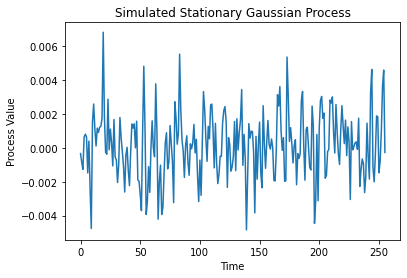

In [19]:
# Define an example autocovariance function.
# For instance, for an AR(1) process with parameter phi, the autocovariance at lag k is:
# acvs[k] = sigma^2 * phi^k / (1 - phi^2), for k >= 0.

def r(Npower2, tau, sigma):
    lags = np.arange(Npower2)
    return sigma ** 2 * np.exp(- (lags/ tau) ** 2)


def acvs_fun_example(Npower2, phi=0.8, sigma=1.0):
    # Generate autocovariance for lags 0, 1, ..., Npower2-1.
    lags = np.arange(Npower2)
    return sigma**2 * (phi ** lags) / (1 - phi**2)

# Simulation parameters.
N = 256  # desired time series length
phi = 0.8
sigma = 1.0
tau = 1.0

# Perform the simulation.
# x = davies_harte_sim(N, acvs_fun_example, phi=phi, sigma=sigma)
x = davies_harte_sim(N, r, tau=tau, sigma=sigma)

# Plot the simulated series (requires matplotlib).
try:
    import matplotlib.pyplot as plt
    plt.plot(x)
    plt.title("Simulated Stationary Gaussian Process")
    plt.xlabel("Time")
    plt.ylabel("Process Value")
    plt.show()
except ImportError:
    print("matplotlib is not installed; skipping plot.")